In [1]:


# ── Cell 1: Imports, Seed, Config ────────────────────────────
#
# PORTABLE sys.path BOOTSTRAP
# This notebook lives at clients/main_framework/MLP_depression*.ipynb
# → project root is two levels up from os.getcwd()
#
import sys, os, time, pickle, warnings

_HERE         = os.path.abspath(os.getcwd())            # .../clients/main_framework
_PROJECT_ROOT = os.path.dirname(os.path.dirname(_HERE)) # .../project
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="opacus")

from utils.seed import fix_all_seeds
fix_all_seeds()

import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from opacus import PrivacyEngine

from config import *          # pulls BASE_PATH, RESULTS_PATH, AGGREGATED_GRAD_FILE, …
from utils.logger import log_round

# ── Client identity ───────────────────────────────────────────
# For hospital_1: CLIENT_ID = "hospital_1", DATA_FILE = "Final_Depression1_anonymised.csv"
# For hospital_2: CLIENT_ID = "hospital_2", DATA_FILE = "Final_Depression2_anonymised.csv"
# For hospital_3: CLIENT_ID = "hospital_3", DATA_FILE = "Final_Depression3_anonymised.csv"
CLIENT_ID = "hospital_2"
DATA_FILE = "Final_Depression2_anonymised.csv"

MODEL_FILE           = os.path.join(RESULTS_PATH, f"{CLIENT_ID}_local_model.pth")
GLOBAL_GRADIENT_FILE = AGGREGATED_GRAD_FILE   # ← from config, no hardcoding

print(f"[CONFIG] Client     : {CLIENT_ID}")
print(f"[CONFIG] Experiment : {EXPERIMENT_NAME}")
print(f"[CONFIG] DP enabled : {DP_ENABLED}")
print(f"[CONFIG] HE enabled : {HE_ENABLED}")
print(f"[CONFIG] Seed       : {SEED}")
print(f"[CONFIG] Project root: {BASE_PATH}")

In [2]:
# ── Cell 2: Load Data ─────────────────────────────────────────
data_path = os.path.join(DATA_PATH, DATA_FILE)
df = pd.read_csv(data_path)
print(f"[DATA] Loaded: {data_path}")
print(f"[DATA] Shape:  {df.shape}")
df.head()

Shape: (11696, 39)


,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,orientation,race,...,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,Condition
0,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_1b5799db,TKN_25a81701,...,2,1,7,4,5,7,7,1,1,Severe
1,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,6,7,5,2,4,6,1,3,3,Mild
2,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_1b5799db,TKN_25a81701,...,4,4,5,6,3,7,5,3,1,Moderate
3,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_1b5799db,TKN_25a81701,...,4,5,5,5,5,7,5,3,1,Moderate
4,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_130c5b34,TKN_05b81f76,TKN_2c94cae9,TKN_25a81701,...,5,4,5,5,4,6,5,1,2,Extremely Severe


In [3]:
# ── Cell 3: Preprocessing ─────────────────────────────────────
target_column = 'Condition'
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

le_target = LabelEncoder()
df_encoded[target_column] = le_target.fit_transform(df_encoded[target_column])

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

print(f"[PREP] Features: {X.shape[1]}")
print(f"[PREP] Samples:  {X.shape[0]}")
print(f"[PREP] Classes:  {list(le_target.classes_)}")

In [4]:
# ── Cell 4: Train/Test Split ──────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=SEED       # ← from config
)
print(f"[SPLIT] Train: {X_train.shape[0]}  Val: {X_val.shape[0]}")
print(f"[SPLIT] Class distribution (train):\n"
      f"{pd.Series(y_train).value_counts().sort_index()}")

In [5]:
# ── Cell 5: SMOTE ─────────────────────────────────────────────
smote = SMOTE(random_state=SEED)    # ← from config
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"[SMOTE] Before: {X_train.shape[0]}  After: {X_train_sm.shape[0]}")
print(f"[SMOTE] Class distribution after:\n"
      f"{pd.Series(y_train_sm).value_counts().sort_index()}")

In [6]:
# ── Cell 6: DataLoaders ───────────────────────────────────────
X_train_tensor = torch.tensor(X_train_sm.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sm,         dtype=torch.long)
X_val_tensor   = torch.tensor(X_val.values,       dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val.values,       dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"[DATA] Train batches: {len(train_loader)}")
print(f"[DATA] Val batches:   {len(val_loader)}")

In [7]:
# ── Cell 7: Model Definition ──────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, HIDDEN_DIM_1),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM_1, HIDDEN_DIM_2),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM_2, num_classes)
        )
    def forward(self, x):
        return self.model(x)

input_dim  = X_train_sm.shape[1]
num_classes = OUTPUT_DIM
model = MLP(input_dim, num_classes)

total_params = sum(p.numel() for p in model.parameters())
print(f"[MODEL] Input dim:  {input_dim}")
print(f"[MODEL] Architecture: {input_dim} → "
      f"{HIDDEN_DIM_1} → {HIDDEN_DIM_2} → {num_classes}")
print(f"[MODEL] Total parameters: {total_params}")

In [8]:
# ── Cell 8: Optimizer and Privacy Engine ──────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

if DP_ENABLED:
    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )
    print(f"[DP] Privacy engine attached")
    print(f"[DP] Noise multiplier: {NOISE_MULTIPLIER}")
    print(f"[DP] Max grad norm:    {MAX_GRAD_NORM}")
else:
    privacy_engine = None
    print("[DP] Differential privacy DISABLED for this variant")

C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [9]:
# ── Cell 9: Local Training ────────────────────────────────────
import time

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    start = time.time()

    # Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            out = model(X_batch)
            val_loss += criterion(out, y_batch).item()
            all_preds.extend(torch.argmax(out, dim=1).numpy())
            all_labels.extend(y_batch.numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    elapsed = time.time() - start

    epsilon = (privacy_engine.get_epsilon(delta=DELTA)
               if DP_ENABLED else None)

    # Log every epoch
    log_round(
        client_id=CLIENT_ID,
        fl_round=epoch,
        val_accuracy=round(val_acc, 4),
        train_loss=round(train_loss, 4),
        val_loss=round(val_loss, 4),
        epsilon=round(epsilon, 4) if epsilon else None,
        elapsed_seconds=round(elapsed, 2)
    )

    eps_str = f" | ε={epsilon:.4f}" if epsilon else ""
    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}{eps_str}")

    # Early stopping on val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_FILE)
        print(f"  ✓ Best model saved → {MODEL_FILE}")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"[STOP] Early stopping at epoch {epoch+1}")
            break

if DP_ENABLED:
    final_epsilon = privacy_engine.get_epsilon(delta=DELTA)
    print(f"\n[DP] Final ε = {final_epsilon:.4f} at δ = {DELTA}")

Epoch 1 - Training Loss: 333.6757 - Validation Loss: 0.9734
New best model saved!
Epoch 2 - Training Loss: 239.1145 - Validation Loss: 0.7759
New best model saved!
Epoch 3 - Training Loss: 211.4514 - Validation Loss: 0.7154
New best model saved!
Epoch 4 - Training Loss: 198.7447 - Validation Loss: 0.6734
New best model saved!
Epoch 5 - Training Loss: 189.8385 - Validation Loss: 0.6732
New best model saved!
Epoch 6 - Training Loss: 183.8130 - Validation Loss: 0.7518
Epoch 7 - Training Loss: 187.5829 - Validation Loss: 0.6903
Epoch 8 - Training Loss: 185.7576 - Validation Loss: 0.7329
Epoch 9 - Training Loss: 195.3686 - Validation Loss: 0.8363
Epoch 10 - Training Loss: 196.2336 - Validation Loss: 0.8465
Epoch 11 - Training Loss: 194.7598 - Validation Loss: 0.8479
Epoch 12 - Training Loss: 202.0045 - Validation Loss: 0.8284
Epoch 13 - Training Loss: 201.2879 - Validation Loss: 0.9097
Epoch 14 - Training Loss: 199.7675 - Validation Loss: 0.9116
Epoch 15 - Training Loss: 198.3619 - Validati

In [10]:
import os
from config import RESULTS_PATH

# Check 1: Log file created
log_path = os.path.join(RESULTS_PATH, "fl_anon_dp_he.jsonl")
print(f"✓ Log file exists: {os.path.exists(log_path)}")

# Check 2: Model file saved
model_path = os.path.join(RESULTS_PATH, "hospital_1_local_model.pth")
print(f"✓ Model saved: {os.path.exists(model_path)}")

# Check 3: Show last 2 log entries
if os.path.exists(log_path):
    import json
    with open(log_path) as f:
        lines = f.readlines()
    print(f"✓ Total log entries: {len(lines)}")
    print(f"  Last entry: {json.loads(lines[-1])['metrics']}")


 Training Accuracy: 0.7848
 Validation Accuracy: 0.7833

Classification Report (Validation):
                  precision    recall  f1-score   support

Extremely Severe       0.92      0.87      0.89       782
            Mild       0.53      0.73      0.61       234
        Moderate       0.75      0.68      0.71       411
          Normal       0.98      0.78      0.87       517
          Severe       0.60      0.75      0.67       396

        accuracy                           0.78      2340
       macro avg       0.76      0.76      0.75      2340
    weighted avg       0.81      0.78      0.79      2340


 Differential Privacy Epsilon: 1.91 (δ=1e-5)


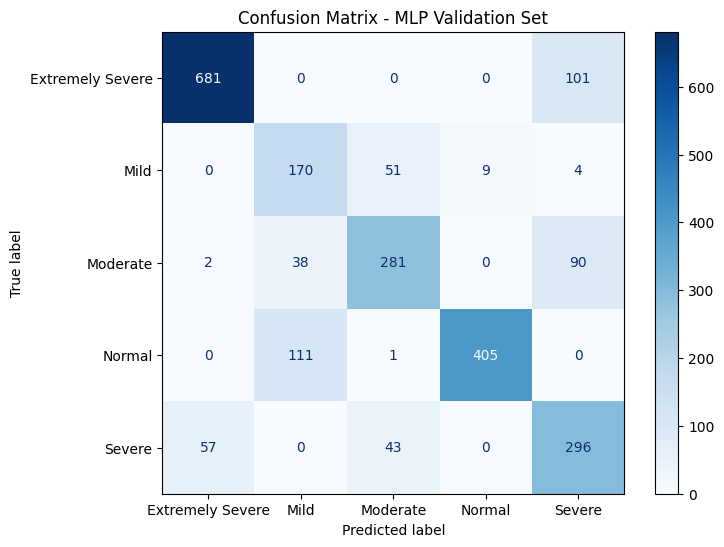

In [11]:
# ── Cell 10: CKKS Context + Helpers ──────────────────────────
import tenseal as ts
import pickle, os, requests, warnings
warnings.filterwarnings("ignore")

from config import (
    POLY_MODULUS_DEGREE, COEFF_MOD_BITS, GLOBAL_SCALE,
    CHUNK_SIZE, SERVER_URL, RESULTS_PATH
)

def get_ckks_context():
    ctx = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=POLY_MODULUS_DEGREE,
        coeff_mod_bit_sizes=COEFF_MOD_BITS
    )
    ctx.global_scale = GLOBAL_SCALE
    ctx.generate_galois_keys()
    return ctx

ckks_context    = get_ckks_context()
public_context  = ckks_context.serialize(save_secret_key=False)

# Save public context for server
context_path = os.path.join(RESULTS_PATH, "context.ser")
with open(context_path, "wb") as f:
    f.write(public_context)
print(f"[HE] CKKS context ready  (poly_mod={POLY_MODULUS_DEGREE})")
print(f"[HE] Public context saved → {context_path}")


def flatten_gradients(mdl):
    grads = [p.grad.view(-1).cpu()
             for p in mdl.parameters() if p.grad is not None]
    flat = torch.cat(grads)
    print(f"[HE] Flattened gradient length: {len(flat)}")
    return flat


def encrypt_gradients(flat_grads, pub_ctx):
    n_chunks = (len(flat_grads) + CHUNK_SIZE - 1) // CHUNK_SIZE
    chunks   = torch.chunk(flat_grads, n_chunks)
    ctx      = ts.context_from(pub_ctx)
    ctx.make_context_public()
    encrypted = []
    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted.append(enc)
        print(f"[HE] Encrypted chunk {i} ({len(chunk)} values)")
    return encrypted


def send_encrypted_chunks(enc_chunks, url, client_id):
    for i, enc in enumerate(enc_chunks):
        payload = pickle.dumps({
            'chunk_id':  i,
            'client_id': client_id,
            'data':      enc.serialize()
        })
        try:
            r = requests.post(
                url, data=payload,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False
            )
            status = "OK" if r.status_code == 200 else f"HTTP {r.status_code}"
            print(f"[HE] Sent chunk {i} ({len(payload)} bytes) → {status}")
        except Exception as e:
            print(f"[HE] Error sending chunk {i}: {e}")


def receive_and_apply_gradient(mdl, ctx, grad_file):
    with open(grad_file, "rb") as f:
        serialized_chunks = pickle.load(f)

    decrypted_parts = []
    for i, chunk_ser in enumerate(serialized_chunks):
        enc  = ts.ckks_vector_from(ctx, chunk_ser)
        dec  = torch.tensor(enc.decrypt(), dtype=torch.float32)
        decrypted_parts.append(dec)
        print(f"[HE] Decrypted chunk {i} ({len(dec)} values)")

    global_grad = torch.cat(decrypted_parts)
    print(f"[HE] Total gradient length: {len(global_grad)}")

    # Clip
    norm = global_grad.norm()
    if norm > 1e2:
        global_grad = global_grad / norm * 1e2
        print(f"[HE] Gradient clipped (original norm: {norm:.2e})")

    # Apply
    ptr = 0
    for param in mdl.parameters():
        if param.grad is not None:
            sz    = param.grad.numel()
            param.data -= global_grad[ptr:ptr+sz].view(param.grad.shape)
            ptr  += sz
    print("[HE] Global gradient applied to model")


def evaluate(mdl, loader, crit, split="Val"):
    mdl.eval()
    total_loss, preds, labels = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = mdl(xb)
            total_loss += crit(out, yb).item()
            preds.extend(torch.argmax(out, dim=1).numpy())
            labels.extend(yb.numpy())
    acc = accuracy_score(labels, preds)
    print(f"[EVAL] {split} → Acc: {acc:.4f}  Loss: {total_loss:.4f}")
    return acc, total_loss, preds, labels

In [ ]:
# CKKS sanity check
test_vector = [0.1, 0.2, 0.3, 0.4, 0.5]
ctx_test = ts.context_from(public_context)
ctx_test.make_context_public()
enc = ts.ckks_vector(ctx_test, test_vector)
dec = ts.ckks_vector_from(ckks_context, enc.serialize()).decrypt()
print(f"[HE] Original:  {test_vector}")
print(f"[HE] Decrypted: {[round(x,4) for x in dec[:5]]}")
print(f"[HE] ✓ CKKS working correctly")

# Check context file saved
context_path = os.path.join(RESULTS_PATH, "context.ser")
print(f"[HE] Context file saved: {os.path.exists(context_path)}")

In [ ]:
# ── Cell 11: Federated Learning Loop ─────────────────────────
# Load best local model weights from training

import time, os, pickle, warnings
warnings.filterwarnings("ignore")

from config import (
    RESULTS_PATH, SERVER_URL, FL_ROUNDS,
    HE_ENABLED, LEARNING_RATE, EARLY_STOPPING_PATIENCE,
    BATCH_SIZE, DELTA
)
from utils.logger import log_round
from sklearn.metrics import accuracy_score, classification_report

CLIENT_ID = "hospital_3"
MODEL_FILE = os.path.join(RESULTS_PATH, f"{CLIENT_ID}_local_model.pth")
GLOBAL_GRADIENT_FILE = os.path.join(
    "/Users/ravi/Desktop/Paper/hybrid-privacy-fl-healthcare",
    "aggregated_gradient_global_encrypted.pkl"
)

global_model = MLP(input_dim, num_classes)
state_dict   = torch.load(MODEL_FILE)
# Strip _module. prefix added by Opacus if present
fixed_sd = {k.replace("_module.", ""): v for k, v in state_dict.items()}
global_model.load_state_dict(fixed_sd, strict=False)
print(f"[FL] Loaded model from {MODEL_FILE}")

fl_criterion = nn.CrossEntropyLoss()
fl_optimizer = torch.optim.Adam(
    global_model.parameters(), lr=LEARNING_RATE
)

best_val_loss = float('inf')
patience_counter = 0

for fl_round in range(FL_ROUNDS):
    print(f"\n{'='*50}")
    print(f"  Federated Round {fl_round + 1} / {FL_ROUNDS}")
    print(f"{'='*50}")
    round_start = time.time()

    # STEP 1: Local training pass
    global_model.train()
    round_train_loss = 0.0
    for xb, yb in train_loader:
        fl_optimizer.zero_grad()
        out  = global_model(xb)
        loss = fl_criterion(out, yb)
        loss.backward()
        fl_optimizer.step()
        round_train_loss += loss.item()

    # STEP 2: Send encrypted gradients to server
    if HE_ENABLED:
        grads     = flatten_gradients(global_model)
        enc_grads = encrypt_gradients(grads, public_context)
        send_encrypted_chunks(enc_grads, SERVER_URL, CLIENT_ID)
    else:
        # No-HE variant: send raw gradients as JSON
        grads = flatten_gradients(global_model)
        r = requests.post(
            SERVER_URL + "/raw",
            json={"client_id": CLIENT_ID,
                  "gradients": grads.tolist()},
            verify=False
        )
        print(f"[FL] Sent raw gradients → HTTP {r.status_code}")

    # STEP 3: Wait for server to aggregate
    # Poll for aggregated file — no manual input needed
    print(f"[FL] Waiting for aggregated gradient file...")
    wait_start = time.time()
    while not os.path.exists(GLOBAL_GRADIENT_FILE):
        time.sleep(2)
        if time.time() - wait_start > 300:   # 5 min timeout
            print("[FL] Timeout waiting for server. Skipping round.")
            break

    # STEP 4: Receive and apply global gradient
    if HE_ENABLED:
        receive_and_apply_gradient(
            global_model, ckks_context, GLOBAL_GRADIENT_FILE
        )
    else:
        with open(GLOBAL_GRADIENT_FILE, "rb") as f:
            global_grad = torch.tensor(pickle.load(f), dtype=torch.float32)
        ptr = 0
        for param in global_model.parameters():
            if param.grad is not None:
                sz = param.grad.numel()
                param.data -= global_grad[ptr:ptr+sz].view(param.grad.shape)
                ptr += sz

    # STEP 5: Evaluate
    val_acc, val_loss, val_preds, val_labels = evaluate(
        global_model, val_loader, fl_criterion, "Val"
    )
    train_acc, train_loss, _, _ = evaluate(
        global_model, train_loader, fl_criterion, "Train"
    )

    elapsed = time.time() - round_start
    print(f"[FL] Round {fl_round+1} complete in {elapsed:.1f}s")
    print(classification_report(val_labels, val_preds, zero_division=0))

    # STEP 6: Log round result
    log_round(
        client_id=CLIENT_ID,
        fl_round=fl_round + 1,
        val_accuracy=round(val_acc, 4),
        train_loss=round(train_loss, 4),
        val_loss=round(val_loss, 4),
        epsilon=None,           # DP already spent in local training
        elapsed_seconds=round(elapsed, 2)
    )

    # STEP 7: Early stopping + save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        save_path = os.path.join(
            RESULTS_PATH, f"{CLIENT_ID}_global_model.pth"
        )
        torch.save(global_model.state_dict(), save_path)
        print(f"[FL] ✓ Best global model saved → {save_path}")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"[FL] Early stopping at round {fl_round+1}")
            break

    # Clean up aggregated file so next round waits fresh
    if os.path.exists(GLOBAL_GRADIENT_FILE):
        os.remove(GLOBAL_GRADIENT_FILE)

print(f"\n[FL] Training complete. Best val loss: {best_val_loss:.4f}")

In [12]:
# Run in terminal or ! in Jupyter
!pip install tenseal

In [13]:
import tenseal as ts
import numpy as np
import torch

In [14]:
import tenseal as ts
print(ts.__version__)


0.3.16


In [15]:
# Simulate a dummy gradient from a layer (e.g., 5 parameters)
local_gradient = torch.tensor([0.25, -0.3, 0.1, 0.55, -0.12], dtype=torch.float32)

print("Original Gradient (Local Model):")
print(local_gradient.numpy())


Original Gradient (Local Model):
[ 0.25 -0.3   0.1   0.55 -0.12]


In [16]:
# CKKS encryption context setup
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.generate_galois_keys()
context.global_scale = 2**40

# Save public & secret key (just for simulation; normally private key stays secure)
public_context = context.copy()  # This is what would be shared with the server
public_context.make_context_public()  # Only allows encryption



In [17]:
import torch

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [18]:
def encrypt_gradients_from_model(model, X_batch, y_batch, loss_fn, context):
    model.train()
    model.zero_grad()

    outputs = model(X_batch)
    loss = loss_fn(outputs, y_batch)
    loss.backward()

    encrypted_grads = {}

    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad = param.grad.view(-1).detach().cpu().numpy()
            enc_grad = ts.ckks_vector(context, grad.tolist())
            encrypted_grads[name] = enc_grad

            print(f"\n Layer: {name}")
            print(f"    Original Gradient Sample: {grad[:5]}")
            print(f"    Encrypted Gradient Sample (decrypted view): {enc_grad.decrypt()[:5]}")

    return encrypted_grads

In [19]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

# Get one batch from your train loader
X_sample, y_sample = next(iter(train_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

# Run encryption on gradients
encrypted_grads = encrypt_gradients_from_model(model, X_sample, y_sample, loss_fn, context)


The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.

 Layer: _module.model.0.weight
    Original Gradient Sample: [0.0000000e+00 0.0000000e+00 0.0000000e+00 7.2523973e-09 7.2523973e-09]
    Encrypted Gradient Sample (decrypted view): [-3.184067167913418e-10, 2.6492363615349124e-09, -6.228684048571742e-10, 7.34833893734077e-09, 2.8841300545728865e-09]

 Layer: _module.model.0.bias
    Original Gradient Sample: [ 7.2523973e-09  0.0000000e+00 -6.0497941e-03  0.0000000e+00
  0.0000000e+00]
    Encrypted Gradient Sample (decrypted view): [8.093267335628213e-09, -5.699244804309918e-10, -0.006049793434403926, -3.5428399266129514e-10, 5.652124288529679e-10]
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter,

In [20]:
import torch
import tenseal as ts
import pickle
import requests
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------
# CKKS Setup 
# -------------------------------
def get_ckks_context():
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    context.global_scale = 2**40
    context.generate_galois_keys()
    return context

ckks_context = get_ckks_context()
public_context = ckks_context.serialize(save_secret_key=False)

# -------------------------------
# Gradient Flattening
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    print(f"[DEBUG] Flattened gradient length: {len(flat)}")
    return flat

# -------------------------------
# Encrypt Gradients with CKKS
# -------------------------------
def encrypt_gradients(flattened_grads, context, chunk_size=8000):
    if len(flattened_grads) > chunk_size:
        print("[WARNING] Gradient too large for single CKKS vector (>8192). Chunking.")
        chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    else:
        chunks = [flattened_grads]

    encrypted_chunks = []
    ctx = ts.context_from(context)
    ctx.make_context_public()

    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted_chunks.append(enc)
        print(f"[DEBUG] Encrypted chunk {i} with {len(chunk)} values")

    return encrypted_chunks

def send_encrypted_chunks_binary(encrypted_chunks, server_url, client_id="hospital_2"):
    for i, enc_chunk in enumerate(encrypted_chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,  
                'data': enc_chunk.serialize()
            }
            data = pickle.dumps(payload)

            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False 
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")

# -------------------------------
# Client Main Routine
# -------------------------------
def run_client_post_training(model):
    print("[CLIENT] Preparing gradients...")
    grads = flatten_gradients(model)
    enc_chunks = encrypt_gradients(grads, public_context)

    print("[CLIENT] Sending encrypted gradients...")
    send_encrypted_chunks_binary(enc_chunks, server_url="https://127.0.0.1:5055")
    
run_client_post_training(model)


[CLIENT] Preparing gradients...
[DEBUG] Flattened gradient length: 13573
[WARNING] Gradient too large for single CKKS vector (>8192). Chunking.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values
[CLIENT] Sending encrypted gradients...


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 0 (668947 bytes)
[CLIENT] Sent chunk 1 (668782 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [21]:
import torch
import torch.nn as nn
import pickle
import tenseal as ts
from sklearn.metrics import classification_report
import warnings
import os
import shutil
import requests

warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------
# Define MLP Architecture
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, output_dim=5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# -------------------------------
# Decrypt + Apply Global Gradient
# -------------------------------
def receive_and_update_model(model, ckks_context, global_gradient_file="aggregated_gradient_global_encrypted.pkl"):
    with open(global_gradient_file, "rb") as f:
        encrypted_chunks_serialized = pickle.load(f)

    decrypted_flattened_grad = []
    for i, chunk_ser in enumerate(encrypted_chunks_serialized):
        enc_chunk = ts.ckks_vector_from(ckks_context, chunk_ser)
        decrypted_chunk = torch.tensor(enc_chunk.decrypt(), dtype=torch.float32)
        decrypted_flattened_grad.append(decrypted_chunk)
        print(f"[CLIENT] Decrypted chunk {i} of size {len(decrypted_chunk)}")

    decrypted_gradient = torch.cat(decrypted_flattened_grad)
    print(f"[CLIENT] Total decrypted global gradient length: {len(decrypted_gradient)}")

    # Clip gradient norm if necessary
    grad_norm = decrypted_gradient.norm()
    if grad_norm > 1e2:
        decrypted_gradient = decrypted_gradient / grad_norm * 1e2
        print(f"[CLIENT] Gradient clipped to norm 1e2 (original norm: {grad_norm:.2e})")

    # Apply gradients to model
    pointer = 0
    for param in model.parameters():
        if param.grad is not None:
            param_shape = param.grad.shape
            param_size = param.grad.numel()
            grad_slice = decrypted_gradient[pointer:pointer + param_size].view(param_shape)
            param.data -= grad_slice
            pointer += param_size

    print("[CLIENT] Global model updated with aggregated global gradient")

# -------------------------------
# Evaluate Model
# -------------------------------
def evaluate_model(model, dataloader, criterion, split_name="Validation"):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = 100.0 * correct / total
    print(f"[CLIENT] {split_name} → Accuracy: {acc:.2f}%, Loss: {total_loss:.4f}")
    return all_preds, all_labels, total_loss

# -------------------------------
# HE Gradient Send Helpers
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    return flat

def encrypt_gradients(flattened_grads, context, chunk_size=8000):
    chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    encrypted_chunks = []
    ctx = ts.context_from(context)
    ctx.make_context_public()

    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted_chunks.append(enc)
        print(f"[DEBUG] Encrypted chunk {i} with {len(chunk)} values")
    return encrypted_chunks

def send_encrypted_chunks_binary(encrypted_chunks, server_url, client_id="hospital_2"):
    for i, enc_chunk in enumerate(encrypted_chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,
                'data': enc_chunk.serialize()
            }
            data = pickle.dumps(payload)
            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")

# -------------------------------
# Main Federated Loop (Last Client)
# -------------------------------
ckks_context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
ckks_context.global_scale = 2**40
ckks_context.generate_galois_keys()
public_context = ckks_context.serialize(save_secret_key=False)

# Init model
sample_batch, _ = next(iter(train_loader))
input_dim = sample_batch.shape[1]
global_model = MLP(input_dim=input_dim, output_dim=5)
state_dict = torch.load("trained_mlp_model.pth")
fixed_state_dict = {k.replace("_module.", ""): v for k, v in state_dict.items()}
global_model.load_state_dict(fixed_state_dict, strict=False)
print("[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(global_model.parameters(), lr=0.01)

best_val_loss = float('inf')
patience = 3
counter = 0
max_rounds = 50

for round in range(max_rounds):
    print(f"\n === Federated Round {round+1} ===")

    # STEP 1: Local training
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 2: Wait for global gradient
    user_in = input("Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'): ").strip().lower()
    if user_in == "exit":
        print("Exiting federated training loop.")
        break

    # STEP 3: Apply global gradient
    receive_and_update_model(global_model, ckks_context)

    # STEP 4: Re-train model (after update)
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 5: Send new gradients
    print("[CLIENT] Encrypting & sending updated gradients...")
    grads = flatten_gradients(global_model)
    encrypted_chunks = encrypt_gradients(grads, public_context)
    send_encrypted_chunks_binary(encrypted_chunks, server_url="https://127.0.0.1:5055", client_id="hospital_2")

    # STEP 6: Evaluation
    evaluate_model(global_model, train_loader, criterion, "Training")
    val_preds, val_labels, val_loss = evaluate_model(global_model, val_loader, criterion, "Validation")
    print("[CLIENT] Validation Classification Report:")
    print(classification_report(val_labels, val_preds, zero_division=0))

    # STEP 7: Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(global_model.state_dict(), "trained_global_model_2.pth")
        print("Best model saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break


[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'

 === Federated Round 1 ===


Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'):  


[CLIENT] Decrypted chunk 0 of size 6787
[CLIENT] Decrypted chunk 1 of size 6786
[CLIENT] Total decrypted global gradient length: 13573
[CLIENT] Gradient clipped to norm 1e2 (original norm: inf)
[CLIENT] Global model updated with aggregated global gradient
[CLIENT] Encrypting & sending updated gradients...
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 0 (668503 bytes)


...

[CLIENT] Sent chunk 0 (669088 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 1 (668644 bytes)
[CLIENT] Training → Accuracy: 82.22%, Loss: 103.3673
[CLIENT] Validation → Accuracy: 81.03%, Loss: 15.7508
[CLIENT] Validation Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       782
           1       0.57      0.74      0.64       234
           2       0.79      0.68      0.73       411
           3       1.00      0.80      0.89       517
           4       0.65      0.79      0.71       396

    accuracy                           0.81      2340
   macro avg       0.78      0.79      0.78      2340
weighted avg       0.83      0.81      0.82      2340

Best model saved.

 === Federated Round 7 ===


Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'):  exit


Exiting federated training loop.


In [ ]:
from utils.logger import log_result

log_result(
    experiment_name="ablation_full_framework",
    client_id="hospital_1",
    metrics={
        "fl_round": round_num,
        "val_accuracy": val_acc,
        "epsilon": epsilon,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "training_time_seconds": elapsed
    }
)